In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)  # show all columns
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('../data/raw/results.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (49287, 9)

Column names: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

First 5 rows:


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
print("Data types:")
print(df.dtypes)

print("\nNull values per column:")
print(df.isnull().sum())

print("\nDate range:")
df['date'] = pd.to_datetime(df['date'])
print(f"Earliest: {df['date'].min()}")
print(f"Latest:   {df['date'].max()}")

Data types:
date              str
home_team         str
away_team         str
home_score    float64
away_score    float64
tournament        str
city              str
country           str
neutral          bool
dtype: object

Null values per column:
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

Date range:
Earliest: 1872-11-30 00:00:00
Latest:   2026-06-27 00:00:00


In [4]:
all_teams = pd.concat([df['home_team'], df['away_team']]).unique()
print(f"Total unique teams: {len(all_teams)}")
print("\nSample teams:", sorted(all_teams)[:20])

Total unique teams: 333

Sample teams: ['Abkhazia', 'Afghanistan', 'Albania', 'Alderney', 'Algeria', 'Ambazonia', 'American Samoa', 'Andalusia', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Arameans Suryoye', 'Argentina', 'Armenia', 'Artsakh', 'Aruba', 'Asturias', 'Australia', 'Austria']


In [5]:
print(df['tournament'].value_counts().head(20))

tournament
Friendly                                18252
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368
Name: count, dtype: int64


In [6]:
def get_outcome(row):
    if row['home_score'] > row['away_score']:
        return 'H'  # Home win
    elif row['home_score'] < row['away_score']:
        return 'A'  # Away win
    else:
        return 'D'  # Draw

df['outcome'] = df.apply(get_outcome, axis=1)

print("Outcome distribution:")
print(df['outcome'].value_counts())
print("\nAs percentages:")
print(df['outcome'].value_counts(normalize=True).round(3) * 100)

Outcome distribution:
outcome
H    24106
A    13912
D    11269
Name: count, dtype: int64

As percentages:
outcome
H    48.9
A    28.2
D    22.9
Name: proportion, dtype: float64


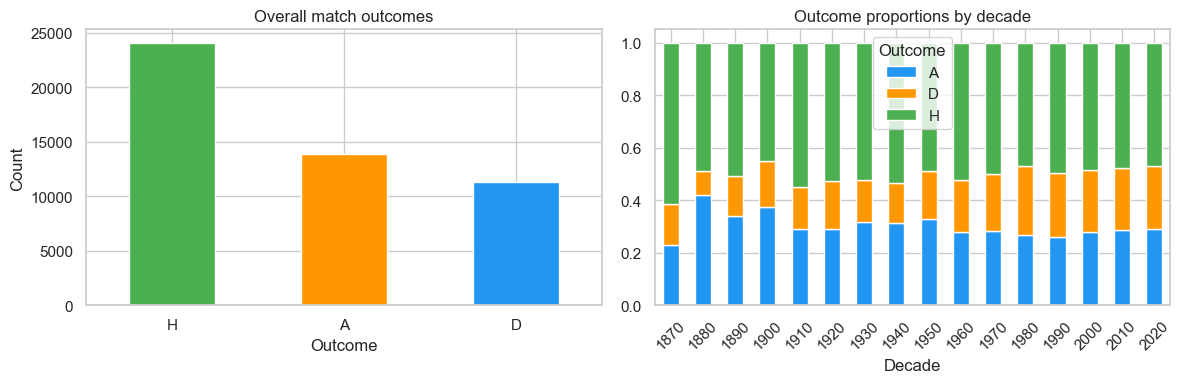

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of outcomes
df['outcome'].value_counts().plot(kind='bar', ax=axes[0], 
    color=['#4CAF50', '#FF9800', '#2196F3'], rot=0)
axes[0].set_title('Overall match outcomes')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')

# Outcomes over time (by decade)
df['decade'] = (df['date'].dt.year // 10) * 10
outcome_by_decade = df.groupby(['decade', 'outcome']).size().unstack(fill_value=0)
outcome_by_decade.div(outcome_by_decade.sum(axis=1), axis=0).plot(
    kind='bar', ax=axes[1], stacked=True, rot=45,
    color=['#2196F3', '#FF9800', '#4CAF50'])
axes[1].set_title('Outcome proportions by decade')
axes[1].set_xlabel('Decade')
axes[1].legend(title='Outcome')

plt.tight_layout()
plt.savefig('../data/processed/outcome_distribution.png', dpi=150)
plt.show()

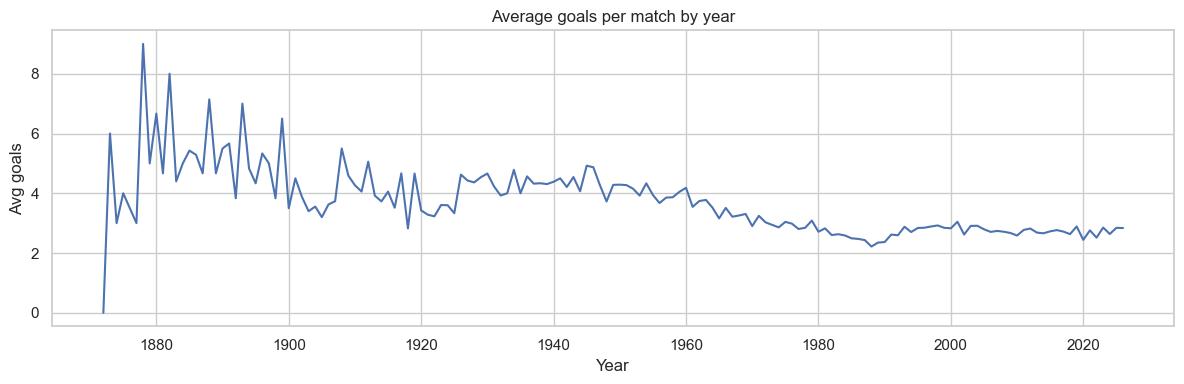

In [8]:
df['total_goals'] = df['home_score'] + df['away_score']

df.groupby(df['date'].dt.year)['total_goals'].mean().plot(
    figsize=(12, 4), title='Average goals per match by year')
plt.ylabel('Avg goals')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

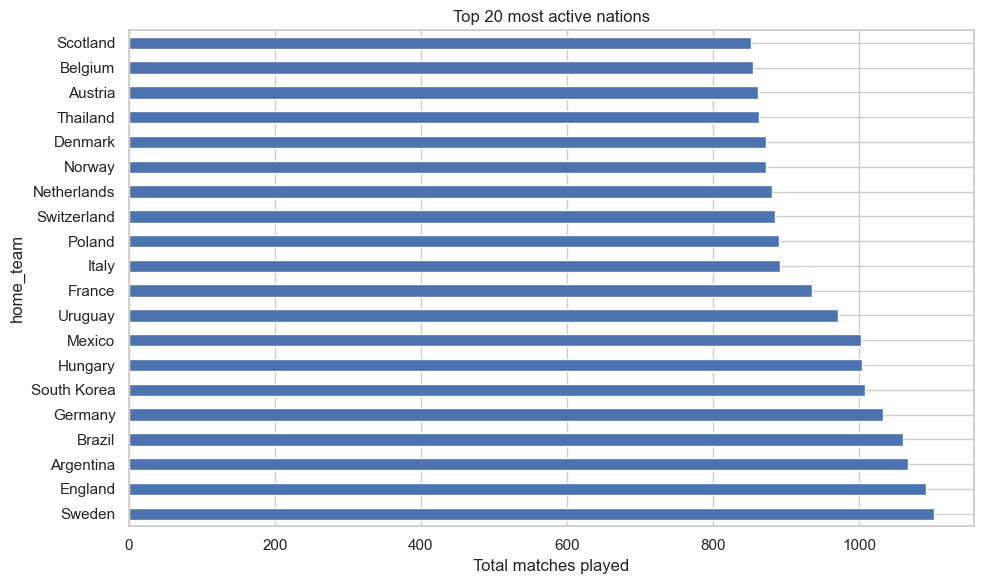

In [9]:
home_counts = df['home_team'].value_counts()
away_counts = df['away_team'].value_counts()
total_games = (home_counts.add(away_counts, fill_value=0)
               .sort_values(ascending=False)
               .head(20))

total_games.plot(kind='barh', figsize=(10, 6), title='Top 20 most active nations')
plt.xlabel('Total matches played')
plt.tight_layout()
plt.show()

In [10]:
# Keep only what we need, sorted by date
df_clean = df[['date', 'home_team', 'away_team', 
               'home_score', 'away_score', 
               'tournament', 'neutral', 'outcome']].copy()

df_clean = df_clean.sort_values('date').reset_index(drop=True)
df_clean.to_csv('../data/processed/matches_clean.csv', index=False)

print(f"Saved {len(df_clean)} rows to data/processed/matches_clean.csv")

Saved 49287 rows to data/processed/matches_clean.csv
